In [10]:
from typing import TypedDict
from pprint import pprint

from langgraph.graph import StateGraph,add_messages
from langchain_community.chat_models import ChatOllama
from IPython.display import Image, display, JSON

In [19]:
class AgentState(TypedDict):
    input: str
    output: str
    messages: list[dict,add_messages]

def node1(state: AgentState) -> AgentState:
    state["output"] = state["input"] + " - node1 executed"
    state["messages"].append(state["output"])
    return state

def node2(state: AgentState) -> AgentState:
    state["output"] = state["input"] + " - node2 executed"
    state["messages"].append(state["output"])
    return state

def node3(state: AgentState) -> AgentState:
    state["output"] = state["input"] + " - node3 executed"
    state["messages"].append(state["output"])
    return state


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("node1", node1)
graph.add_node("node2", node2)
graph.add_node("node3", node3)

graph.set_entry_point("node1")
graph.add_edge("node1", "node2")
graph.add_edge("node2", "node3")
graph.set_finish_point("node3")

app_test = graph.compile()

result = app_test.`invoke`({"input": "Hi", "messages": [], "output": ""})
result["messages"]





['Hi - node1 executed', 'Hi - node2 executed', 'Hi - node3 executed']

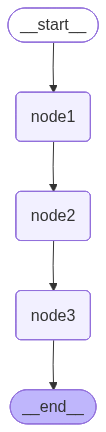

In [14]:
display(Image(app_test.get_graph(xray=True).draw_mermaid_png()))

diaplying the invoke output

'capital of France is Paris'

'What is the capital of France?'

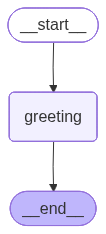

In [14]:

# Show
display(Image(hello_app.get_graph(xray=True).draw_mermaid_png()))